# Behavioral Revenue Intelligence & Customer Strategy Analysis

**Author:** Shivani Gangrade

**Tool:** Google Colab (Python 3)

**Stage:** Data Preparation, Cleaning & Exploratory Data Analysis

**Dataset:** Dim_Customer (1,000) | Dim_Product (45) | Fact_Transactions (9,644)

**Period:** January 2023 – December 2024

---

## Notebook Flow
1. Library Setup
2. Data Loading
3. Data Profiling
4. Master DataFrame *(Star Schema → Python JOIN)*
5. Data Cleaning & Validation
6. Feature Engineering
7. EDA Visualizations *(7 charts)*
8. Export Cleaned Data

## 1. Library Setup

Importing all required libraries for data manipulation and visualization.

- **pandas / numpy** — data manipulation and numerical computations
- **matplotlib / seaborn** — chart creation and styling
- **warnings** — suppress non-critical output for a clean notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Data Loading

Loading all three tables that form the **Star Schema**:

| Table | Type | Description |
|---|---|---|
| Dim_Customer | Dimension | Customer attributes and demographics |
| Dim_Product | Dimension | Product catalog with categories |
| Fact_Transactions | Fact | Purchase events with revenue metrics |

In [ ]:
dim_customer      = pd.read_csv("Dim_Customer.csv")
dim_product       = pd.read_csv("Dim_Product.csv")
fact_transactions = pd.read_csv("Fact_Transactions.csv")

# Parse purchase_date as datetime
# Without this, the column loads as string and time-series grouping won't work
fact_transactions['purchase_date'] = pd.to_datetime(
    fact_transactions['purchase_date']
)

print("Data loaded successfully")

Data loaded successfully


## 3. Data Profiling

Before any transformation, we inspect each table for:
- Row and column dimensions
- Data types per column
- Missing value counts
- Numerical distribution (min, max, mean, std)

This step drives all cleaning decisions made in the next section.

In [ ]:
print("=" * 55)
print("DIM_CUSTOMER — Schema & Quality Check")
print("=" * 55)
display(dim_customer.head(3))
print(dim_customer.info())
print("\nMissing values:\n", dim_customer.isnull().sum())

print("\n" + "=" * 55)
print("DIM_PRODUCT — Schema & Quality Check")
print("=" * 55)
display(dim_product.head(3))
print(dim_product.info())
print("\nMissing values:\n", dim_product.isnull().sum())

print("\n" + "=" * 55)
print("FACT_TRANSACTIONS — Schema & Quality Check")
print("=" * 55)
display(fact_transactions.head(3))
print(fact_transactions.info())
print("\nMissing values:\n", fact_transactions.isnull().sum())
print("\nNumerical Summary:")
display(fact_transactions.describe().round(2))


DIM_CUSTOMER — Schema & Quality Check


,customer_id,customer_name,age,age_group,gender,location,subscription_status,payment_method,frequency_of_purchases
0,1001,Allison Hill,56,Senior,Male,New York,No,Bank Transfer,Monthly
1,1002,Noah Rhodes,69,Senior,Female,Pennsylvania,Yes,Debit Card,Quarterly
2,1003,Angie Henderson,46,Middle-aged,Female,Ohio,Yes,PayPal,Bi-Weekly


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             1000 non-null   int64 
 1   customer_name           1000 non-null   object
 2   age                     1000 non-null   int64 
 3   age_group               1000 non-null   object
 4   gender                  1000 non-null   object
 5   location                1000 non-null   object
 6   subscription_status     1000 non-null   object
 7   payment_method          1000 non-null   object
 8   frequency_of_purchases  1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
None

Missing values:
 customer_id               0
customer_name             0
age                       0
age_group                 0
gender                    0
location                  0
subscription_status       0
payment_method            0
frequency_of_purchases   

,product_id,item_name,category
0,2001,Blouse,Clothing
1,2002,T-Shirt,Clothing
2,2003,Jeans,Clothing


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  45 non-null     int64 
 1   item_name   45 non-null     object
 2   category    45 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.2+ KB
None

Missing values:
 product_id    0
item_name     0
category      0
dtype: int64

FACT_TRANSACTIONS — Schema & Quality Check


,transaction_id,customer_id,product_id,purchase_date,season,purchase_amount,discount_applied,discount_percentage,promo_code_used,shipping_type,review_rating,size_purchased,color_purchased
0,3001,1001,2027,2023-11-21,Fall,288.0,Yes,25,Yes,Express,2.8,M,Purple
1,3002,1001,2007,2024-08-24,Summer,53.0,No,0,No,Standard,3.2,XS,Navy
2,3003,1001,2021,2023-08-29,Summer,124.0,No,0,No,Standard,4.1,S,Green


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9644 entries, 0 to 9643
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       9644 non-null   int64         
 1   customer_id          9644 non-null   int64         
 2   product_id           9644 non-null   int64         
 3   purchase_date        9644 non-null   datetime64[ns]
 4   season               9644 non-null   object        
 5   purchase_amount      9644 non-null   float64       
 6   discount_applied     9644 non-null   object        
 7   discount_percentage  9644 non-null   int64         
 8   promo_code_used      9644 non-null   object        
 9   shipping_type        9644 non-null   object        
 10  review_rating        9644 non-null   float64       
 11  size_purchased       9644 non-null   object        
 12  color_purchased      9644 non-null   object        
dtypes: datetime64[ns](1), float64(2),

,transaction_id,customer_id,product_id,purchase_date,purchase_amount,discount_percentage,review_rating
count,9644.00,9644.00,9644.00,9644,9644.00,9644.00,9644.00
mean,7822.50,1497.47,2023.16,2024-01-01 05:24:09.854831872,88.66,9.18,3.80
min,3001.00,1001.00,2001.00,2023-01-01 00:00:00,7.70,0.00,2.00
25%,5411.75,1247.00,2012.00,2023-06-29 00:00:00,41.00,0.00,3.30
50%,7822.50,1495.50,2023.00,2024-01-05 00:00:00,72.00,0.00,3.90
75%,10233.25,1746.00,2035.00,2024-07-05 00:00:00,117.00,20.00,4.40
max,12644.00,2000.00,2045.00,2024-12-31 00:00:00,499.00,30.00,5.00
std,2784.13,289.59,13.06,NaN,65.94,11.09,0.77


## 4. Master DataFrame — Star Schema JOIN in Python

Replicating the SQL Star Schema JOIN using pandas `.merge()`:
```
Fact_Transactions
    LEFT JOIN Dim_Customer ON customer_id
    LEFT JOIN Dim_Product  ON product_id
```

**Why LEFT JOIN?**
Preserves all transactions even if a dimension record is missing — safer than INNER JOIN for catching referential integrity issues early.

In [ ]:
# Step 1: Join transactions with customer details
df = fact_transactions.merge(dim_customer, on='customer_id', how='left')

# Step 2: Join result with product details
df = df.merge(dim_product, on='product_id', how='left')

print("Master dataframe created:")
display(df.head(3))

Master dataframe created:


,transaction_id,customer_id,product_id,purchase_date,season,purchase_amount,discount_applied,discount_percentage,promo_code_used,shipping_type,...,customer_name,age,age_group,gender,location,subscription_status,payment_method,frequency_of_purchases,item_name,category
0,3001,1001,2027,2023-11-21,Fall,288.0,Yes,25,Yes,Express,...,Allison Hill,56,Senior,Male,New York,No,Bank Transfer,Monthly,Watch,Accessories
1,3002,1001,2007,2024-08-24,Summer,53.0,No,0,No,Standard,...,Allison Hill,56,Senior,Male,New York,No,Bank Transfer,Monthly,Shorts,Clothing
2,3003,1001,2021,2023-08-29,Summer,124.0,No,0,No,Standard,...,Allison Hill,56,Senior,Male,New York,No,Bank Transfer,Monthly,Running Shoes,Footwear


## 5. Data Cleaning & Validation

Validating the merged master dataframe for:

1. **Duplicate transactions** — each transaction_id should appear exactly once
2. **Null values** — nulls post-merge indicate broken foreign key relationships
3. **Categorical values** — confirm no unexpected values in key columns
4. **Date range** — should span January 2023 to December 2024
5. **Revenue sanity** — no negative or zero purchase amounts

In [ ]:
# 1. Duplicate check
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"  → {dupes} duplicates removed")

# 2. Post-merge null check
print("\nMissing values in master dataframe:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "  → No missing values")

# 3. Categorical validation
print(f"\nSubscription values : {df['subscription_status'].unique()}")
print(f"Discount applied    : {df['discount_applied'].unique()}")
print(f"Season values       : {df['season'].unique()}")
print(f"Category values     : {df['category'].unique()}")
print(f"Gender values       : {df['gender'].unique()}")

# 4. Date range validation
print(f"\nDate range  : {df['purchase_date'].min().date()} → {df['purchase_date'].max().date()}")

# 5. Revenue validation
print(f"\nRevenue range : ${df['purchase_amount'].min():,.2f} – ${df['purchase_amount'].max():,.2f}")
print(f"Total revenue : ${df['purchase_amount'].sum():,.2f}")
print(f"Avg order val : ${df['purchase_amount'].mean():,.2f}")

Duplicate rows: 0

Missing values in master dataframe:
  → No missing values

Subscription values : ['No' 'Yes']
Discount applied    : ['Yes' 'No']
Season values       : ['Fall' 'Summer' 'Spring' 'Winter']
Category values     : ['Accessories' 'Clothing' 'Footwear' 'Outerwear']
Gender values       : ['Male' 'Female']

Date range  : 2023-01-01 → 2024-12-31

Revenue range : $7.70 – $499.00
Total revenue : $855,052.60
Avg order val : $88.66


## 6. Feature Engineering

Creating derived columns to enable richer analysis:

| New Column | Logic | Purpose |
|---|---|---|
| purchase_year / month | Extract from purchase_date | Time-series grouping, YoY comparison |
| order_count | Transactions per customer | Basis for lifecycle segmentation |
| customer_segment | New / Returning / Loyal | Lifecycle classification |
| revenue_band | Low / Mid / High / Premium | Spend tier for pricing analysis |
| discount_flag | 0 or 1 | Numeric discount for correlation analysis |

In [ ]:
# Step 1: Count total orders per customer
order_counts = df.groupby('customer_id')['transaction_id'].count()
order_counts = order_counts.reset_index()
order_counts.columns = ['customer_id', 'order_count']
df = df.merge(order_counts, on='customer_id', how='left')

# Step 2: Classify customers into lifecycle segments
def get_segment(order_count):
    if order_count <= 5:
        return 'New'
    elif order_count <= 10:
        return 'Returning'
    else:
        return 'Loyal'

df['customer_segment'] = df['order_count'].apply(get_segment)

# Step 3: Classify transactions into revenue bands
def get_revenue_band(amount):
    if amount <= 50:
        return 'Low (<$50)'
    elif amount <= 100:
        return 'Mid ($50–100)'
    elif amount <= 200:
        return 'High ($100–200)'
    else:
        return 'Premium (>$200)'

df['revenue_band'] = df['purchase_amount'].apply(get_revenue_band)

# Step 4: Extract date parts for time-series analysis
df['purchase_year']  = df['purchase_date'].dt.year
df['purchase_month'] = df['purchase_date'].dt.month
df['month_name']     = df['purchase_date'].dt.strftime('%b')

# Step 5: Numeric discount flag for analysis
df['discount_flag'] = (df['discount_applied'] == 'Yes').astype(int)

print("✅ Feature engineering complete")
print(df['customer_segment'].value_counts())
print(df['revenue_band'].value_counts())

✅ Feature engineering complete
customer_segment
Loyal        4715
Returning    4554
New           375
Name: count, dtype: int64
revenue_band
Mid ($50–100)      3324
Low (<$50)         3166
High ($100–200)    2568
Premium (>$200)     586
Name: count, dtype: int64


## 7. EDA Visualizations

### Chart 1 — Monthly Revenue Trend (2023 vs 2024)

**Business Question:** How is revenue trending month-over-month? Is 2024 performing better than 2023?

**Chart choice:** Grouped bar chart — discrete monthly periods communicate volume better than a continuous line. Color-coded by year for instant visual comparison.

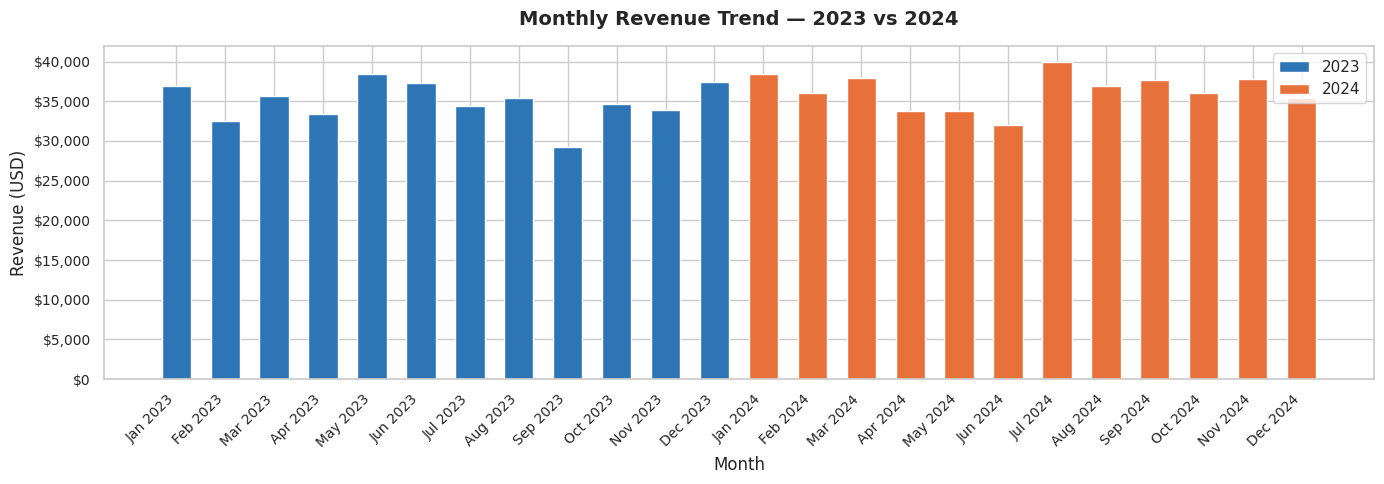

In [ ]:
# Group revenue by year and month
monthly = df.groupby(['purchase_year', 'purchase_month', 'month_name'])['purchase_amount'].sum()
monthly = monthly.reset_index()
monthly = monthly.sort_values(['purchase_year', 'purchase_month'])
monthly['label'] = monthly['month_name'] + ' ' + monthly['purchase_year'].astype(str)

# Split into 2023 and 2024 for easy comparison
data_2023 = monthly[monthly['purchase_year'] == 2023]
data_2024 = monthly[monthly['purchase_year'] == 2024]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(data_2023['label'], data_2023['purchase_amount'], color='#2E75B6', label='2023', width=0.6)
ax.bar(data_2024['label'], data_2024['purchase_amount'], color='#E8703A', label='2024', width=0.6)

ax.set_title('Monthly Revenue Trend — 2023 vs 2024', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Customer Lifecycle Value Analysis

**Business Question:** How much more valuable are Loyal customers compared to New customers?

**Chart choice:** Side-by-side bars — left shows total revenue (volume), right shows avg order value (quality). Together they reveal the complete lifecycle value picture.

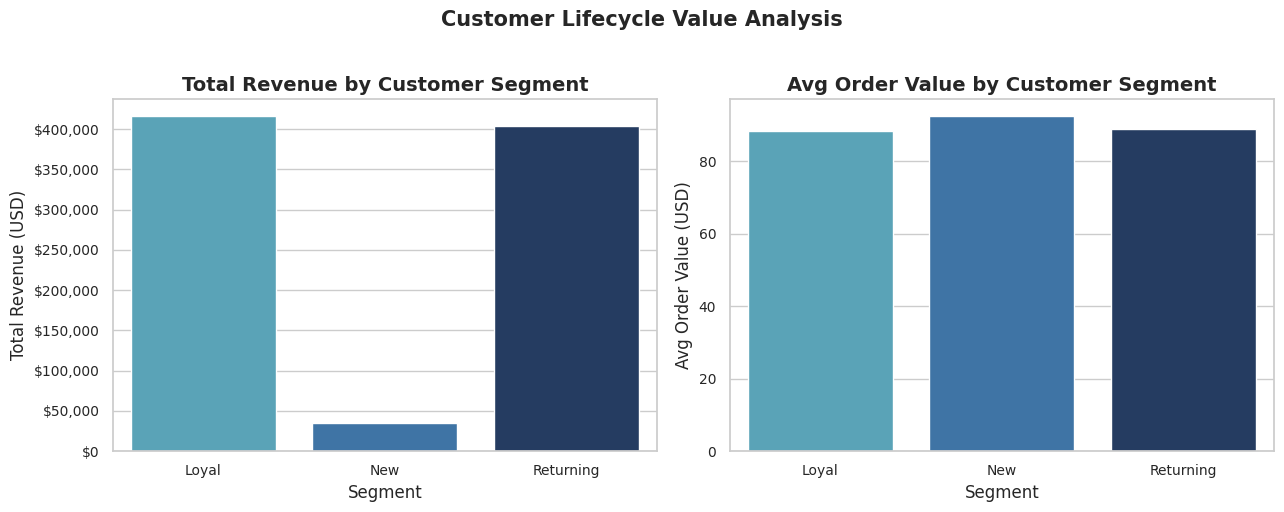

In [ ]:
# Calculate metrics per segment separately — easier to read and explain
seg_revenue = df.groupby('customer_segment')['purchase_amount'].sum().reset_index()
seg_revenue.columns = ['customer_segment', 'total_revenue']

seg_avg = df.groupby('customer_segment')['purchase_amount'].mean().reset_index()
seg_avg.columns = ['customer_segment', 'avg_order_value']

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=seg_revenue, x='customer_segment', y='total_revenue',
            palette=['#4BACC6', '#2E75B6', '#1B3A6B'], ax=axes[0])
axes[0].set_title('Total Revenue by Customer Segment')
axes[0].set_ylabel('Total Revenue (USD)')
axes[0].set_xlabel('Segment')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.barplot(data=seg_avg, x='customer_segment', y='avg_order_value',
            palette=['#4BACC6', '#2E75B6', '#1B3A6B'], ax=axes[1])
axes[1].set_title('Avg Order Value by Customer Segment')
axes[1].set_ylabel('Avg Order Value (USD)')
axes[1].set_xlabel('Segment')

plt.suptitle('Customer Lifecycle Value Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Subscription Program Impact

**Business Question:** Is the subscription program driving measurable revenue and behavioral difference?

**Chart choice:** 3-panel bar — revenue alone doesn't tell the full story. A subscriber might spend less per order but buy far more often. All three panels together reveal the complete picture.

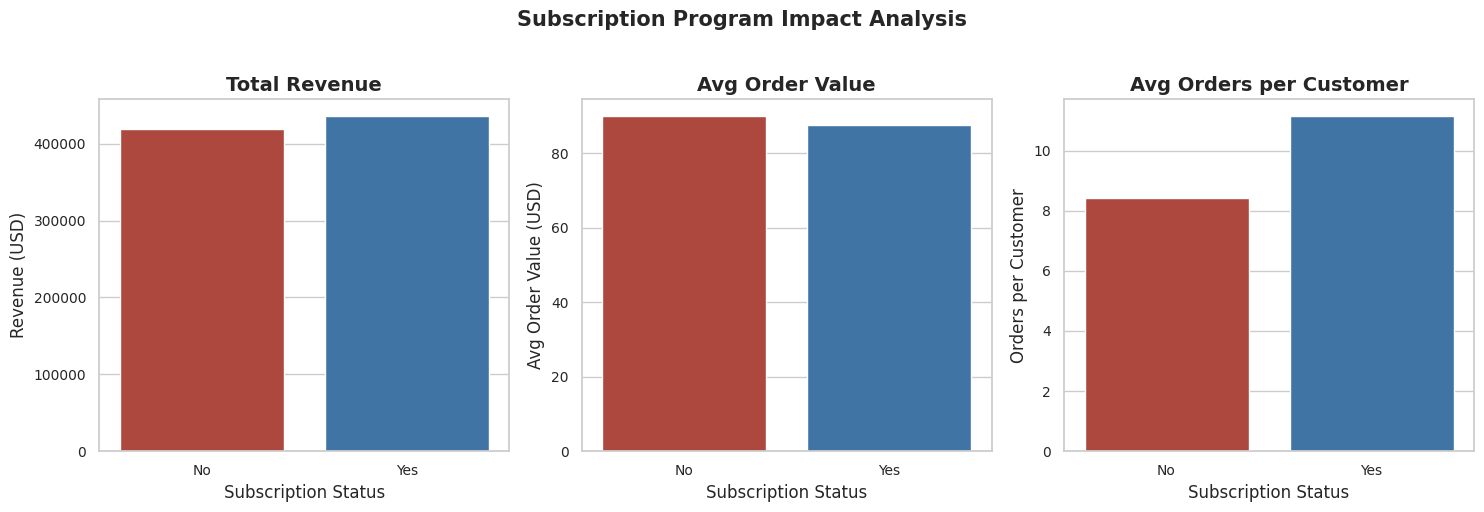

In [ ]:
# Calculate each metric separately
sub_revenue = df.groupby('subscription_status')['purchase_amount'].sum().reset_index()
sub_revenue.columns = ['subscription_status', 'total_revenue']

sub_avg = df.groupby('subscription_status')['purchase_amount'].mean().reset_index()
sub_avg.columns = ['subscription_status', 'avg_order_value']

# Orders per customer — calculate in two steps
total_orders = df.groupby('subscription_status')['transaction_id'].count().reset_index()
total_customers = df.groupby('subscription_status')['customer_id'].nunique().reset_index()
sub_freq = total_orders.merge(total_customers, on='subscription_status')
sub_freq['avg_orders_per_customer'] = sub_freq['transaction_id'] / sub_freq['customer_id']

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = ['#C0392B', '#2E75B6']

sns.barplot(data=sub_revenue, x='subscription_status', y='total_revenue', palette=palette, ax=axes[0])
axes[0].set_title('Total Revenue')
axes[0].set_ylabel('Revenue (USD)')
axes[0].set_xlabel('Subscription Status')

sns.barplot(data=sub_avg, x='subscription_status', y='avg_order_value', palette=palette, ax=axes[1])
axes[1].set_title('Avg Order Value')
axes[1].set_ylabel('Avg Order Value (USD)')
axes[1].set_xlabel('Subscription Status')

sns.barplot(data=sub_freq, x='subscription_status', y='avg_orders_per_customer', palette=palette, ax=axes[2])
axes[2].set_title('Avg Orders per Customer')
axes[2].set_ylabel('Orders per Customer')
axes[2].set_xlabel('Subscription Status')

plt.suptitle('Subscription Program Impact Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_subscription_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4 — Discount & Pricing Intelligence

**Business Question:** Does discounting drive higher spend or attract low-value buyers?

**Chart choice:** 2-panel bar — left compares avg spend (discount vs none), right breaks down revenue by discount depth. Key tension: deep discounts may increase volume but reduce avg order value.

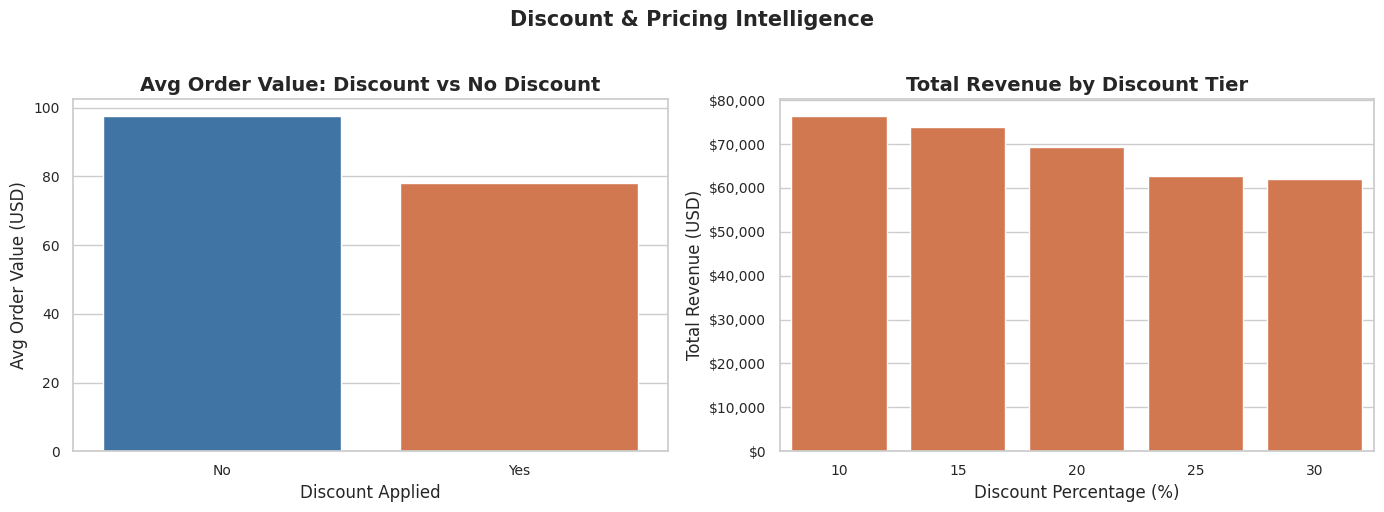

In [ ]:
# Compare avg spend: discounted vs non-discounted
discount_avg = df.groupby('discount_applied')['purchase_amount'].mean().reset_index()
discount_avg.columns = ['discount_applied', 'avg_order_value']

# Revenue by discount percentage (only discounted orders)
discounted_only = df[df['discount_applied'] == 'Yes']
discount_tiers = discounted_only.groupby('discount_percentage')['purchase_amount'].sum().reset_index()
discount_tiers.columns = ['discount_percentage', 'total_revenue']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=discount_avg, x='discount_applied', y='avg_order_value',
            palette=['#2E75B6', '#E8703A'], ax=axes[0])
axes[0].set_title('Avg Order Value: Discount vs No Discount')
axes[0].set_ylabel('Avg Order Value (USD)')
axes[0].set_xlabel('Discount Applied')

sns.barplot(data=discount_tiers, x='discount_percentage', y='total_revenue',
            color='#E8703A', ax=axes[1])
axes[1].set_title('Total Revenue by Discount Tier')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].set_xlabel('Discount Percentage (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Discount & Pricing Intelligence', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5 — Category × Season Revenue Heatmap

**Business Question:** Which product category peaks in which season?

**Chart choice:** Heatmap — shows two dimensions simultaneously (category × season). Darker cells = higher revenue. Instantly identifies which combinations drive the most value for inventory and campaign planning

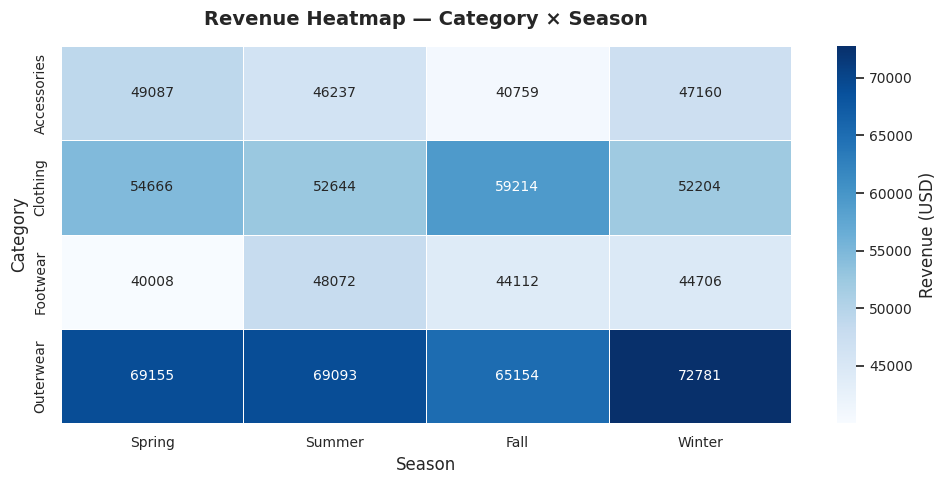

In [ ]:
cat_season = df.groupby(['category', 'season'])['purchase_amount'] \
               .sum().unstack(fill_value=0)
cat_season = cat_season[['Spring', 'Summer', 'Fall', 'Winter']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cat_season, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10},
            cbar_kws={'label': 'Revenue (USD)'})

ax.set_title('Revenue Heatmap — Category × Season', pad=15)
ax.set_ylabel('Category')
ax.set_xlabel('Season')
plt.tight_layout()
plt.savefig('chart5_category_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Chart 6 — Revenue by Age Group & Gender

**Business Question:** Which demographic segment drives the most revenue?

**Chart choice:** Grouped bar chart — comparing two dimensions (age group + gender) simultaneously without needing two separate charts. Identifies the primary target demographic for campaigns.

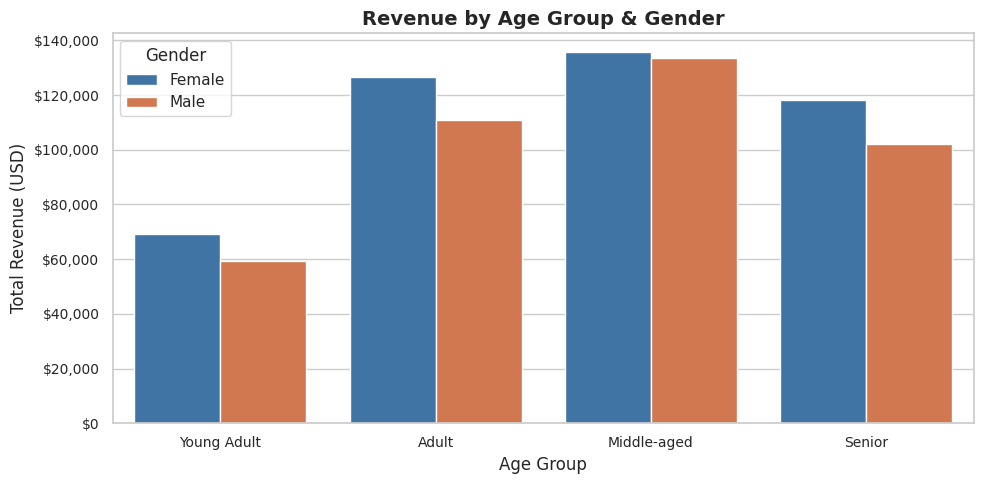

In [ ]:
age_gen = df.groupby(['age_group', 'gender'])['purchase_amount'] \
            .sum().reset_index()

order = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
age_gen['age_group'] = pd.Categorical(age_gen['age_group'],
                                       categories=order, ordered=True)
age_gen = age_gen.sort_values('age_group')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=age_gen, x='age_group', y='purchase_amount',
            hue='gender', palette=['#2E75B6', '#E8703A'], ax=ax)

ax.set_title('Revenue by Age Group & Gender')
ax.set_ylabel('Total Revenue (USD)')
ax.set_xlabel('Age Group')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Gender')
plt.tight_layout()
plt.savefig('chart6_age_gender_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 7 — Top 10 Products by Revenue

**Business Question:** Which products are the top revenue contributors?

**Chart choice:** Horizontal bar chart — product names are long, horizontal layout gives each label enough space without rotation. Gradient color (dark → light) reinforces rank visually. Category labels annotated on each bar for strategic context.

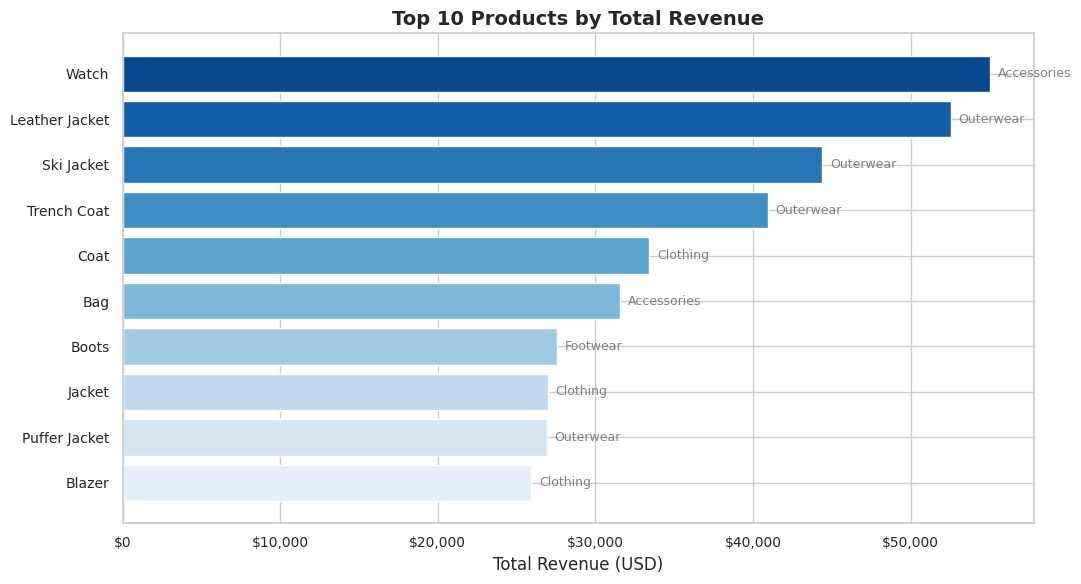

In [ ]:
top_products = df.groupby(['item_name', 'category'])['purchase_amount'] \
                 .sum().reset_index() \
                 .sort_values('purchase_amount', ascending=False) \
                 .head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette('Blues_r', len(top_products))
bars = ax.barh(top_products['item_name'],
               top_products['purchase_amount'], color=colors)

ax.set_title('Top 10 Products by Total Revenue')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()

for bar, (_, row) in zip(bars, top_products.iterrows()):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            row['category'], va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart7_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

Saving all cleaned files for Power BI import:

| File | Contents | Used For |
|---|---|---|
| master_cleaned.csv | All 3 tables merged + engineered features | Flat table analysis |
| Dim_Customer_clean.csv | Cleaned customer dimension | Star schema in Power BI |
| Dim_Product_clean.csv | Cleaned product dimension | Star schema in Power BI |
| Fact_Transactions_clean.csv | Cleaned fact table | Star schema in Power BI |